<font size='+1' color=red>**Attention:**</font> Data cleaning and other parts of preprocessing of data which we covered in the first assignment, is not neccesary all the time but you may need some of them according to task at hand. So we don't explicitly mention them each time. This is your job to figure out when to apply them.

<font size='+1' color=red>**Attention 2:**</font> For your implementations always use `random_state=42` so your code would be reproducible.

## <font color='#D61E85' size='+3'>**Q1:**</font> <font size='+2'> **PCA for Classification** </font>

In this question we want to work with the Fashion-MNIST dataset. Fashion-MNIST is a dataset comprising of $28 \times 28$ grayscale images of $70,000$ fashion products from $10$ categories, with $7,000$ images per category. The training set has $60,000$ images and the test set has $10,000$ images. <br>
<font color=red>**Note:**</font> You can download it from any source you want. <br>
<font color=red>**Note:**</font> Take first $60,000$ instances of it as the train and the $10,000$ remaining instances as the test set.

Using explained varinace ratio and considering a threshold like $95\%$ you probably know how to choose the right number of dimensions to perform PCA. But, when you are using dimensionality reduction as a preprocessing step for a supervised learning task, it is important to consider the impact of the optimal number of dimensions on the overall performance of the model. Consider the classification task using the dataset at hand. Try to find the best number of components for the PCA with respect to the task. You should use the `RandomForestClassifier`, `KNeighborsClassifier`, `DecisionTreeClassifier`, and `AdaBoostClassifier`. Compare your results (number of dimensions, accuracy, precision, recall, f1-score, and confusion matrix) and explain why the number of dimensions for different models are different. Don't forget to analyze your results. [Hint: you should try to make a pipeline and try to tune the hyperparameters of PCA and your model adjointly.]

At the end, perform the hyperparameter tuning but this time without considering the PCA preprocessing step. Compare your results with previous ones.

<font color='#8FCF26' size='+2'>**A1:**</font>

### $$\textbf{Run the Models}$$

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Load the dataset using Pandas
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df = pd.read_csv('fashion-mnist_test.csv')

# Extract the features and target from the data
X_train = train_df.drop('label', axis=1).values / 255.0  # Normalize the pixel values
y_train = train_df['label'].values
X_test = test_df.drop('label', axis=1).values / 255.0  # Normalize the pixel values
y_test = test_df['label'].values


#### $$\textbf{Random Forest}$$

In [6]:

# Define the Random Forest classifier and parameter grid
rf_pipeline = Pipeline([
    ('pca', PCA(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42))
])

rf_param_dist = {
    "pca__n_components": np.arange(50, 100),
    "clf__n_estimators": np.arange(5, 20),
}

# Randomized search
rf_random_search = RandomizedSearchCV(rf_pipeline, rf_param_dist, n_iter=10, cv=3, random_state=42)
rf_random_search.fit(X_train, y_train)

# Best parameters and model
rf_best_params = rf_random_search.best_params_
rf_best_model = rf_random_search.best_estimator_

# Predictions and Evaluations
rf_y_pred = rf_best_model.predict(X_test)

print("\n---Random Forest Classifier---")
print("Best parameters found: ", rf_best_params)
print("Classification Report: \n", classification_report(y_test, rf_y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, rf_y_pred))


---Random Forest Classifier---
Best parameters found:  {'pca__n_components': 86, 'clf__n_estimators': 19}
Classification Report: 
               precision    recall  f1-score   support

           0       0.77      0.85      0.81      1000
           1       0.99      0.96      0.97      1000
           2       0.76      0.80      0.78      1000
           3       0.87      0.89      0.88      1000
           4       0.79      0.82      0.80      1000
           5       0.92      0.92      0.92      1000
           6       0.70      0.56      0.62      1000
           7       0.90      0.89      0.90      1000
           8       0.95      0.95      0.95      1000
           9       0.91      0.94      0.93      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.85     10000
weighted avg       0.86      0.86      0.85     10000

Confusion Matrix: 
 [[848   0  20  38   2   1  76   2  13   0]
 [  5 957  10  20   2   1   5   0   0   0]
 [ 

#### $$\textbf{K-Nearest Neighbors}$$

In [7]:
from sklearn.neighbors import KNeighborsClassifier

# Define the K-Nearest Neighbors classifier and parameter grid
knn_pipeline = Pipeline([
    ('pca', PCA(random_state=42)),
    ('clf', KNeighborsClassifier())
])

knn_param_dist = {
    "pca__n_components": np.arange(50, 100),
    "clf__n_neighbors": np.arange(5, 10),
    "clf__weights": ['uniform', 'distance']
}

# Randomized search
knn_random_search = RandomizedSearchCV(knn_pipeline, knn_param_dist, n_iter=10, cv=3, random_state=42)
knn_random_search.fit(X_train, y_train)

# Best parameters and model
knn_best_params = knn_random_search.best_params_
knn_best_model = knn_random_search.best_estimator_

# Predictions and Evaluations
knn_y_pred = knn_best_model.predict(X_test)

print("\n---K-Nearest Neighbors Classifier---")
print("Best parameters found: ", knn_best_params)
print("Classification Report: \n", classification_report(y_test, knn_y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, knn_y_pred))


---K-Nearest Neighbors Classifier---
Best parameters found:  {'pca__n_components': 71, 'clf__weights': 'uniform', 'clf__n_neighbors': 6}
Classification Report: 
               precision    recall  f1-score   support

           0       0.76      0.88      0.82      1000
           1       0.99      0.97      0.98      1000
           2       0.77      0.81      0.79      1000
           3       0.90      0.90      0.90      1000
           4       0.79      0.81      0.80      1000
           5       0.97      0.88      0.92      1000
           6       0.71      0.56      0.63      1000
           7       0.89      0.94      0.91      1000
           8       0.97      0.97      0.97      1000
           9       0.91      0.95      0.93      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.86     10000
weighted avg       0.87      0.87      0.86     10000

Confusion Matrix: 
 [[881   1  14  16   3   0  76   2   7   0]
 [  6 969   3  

#### $$\textbf{Decision Tree}$$

In [8]:
from sklearn.tree import DecisionTreeClassifier

# Define the Decision Tree classifier and parameter grid
dt_pipeline = Pipeline([
    ('pca', PCA(random_state=42)),
    ('clf', DecisionTreeClassifier(random_state=42))
])

dt_param_dist = {
    "pca__n_components": np.arange(50, 100),
    "clf__min_samples_split": np.arange(20, 30),
    "clf__min_samples_leaf": np.arange(10, 25)
}

# Randomized search
dt_random_search = RandomizedSearchCV(dt_pipeline, dt_param_dist, n_iter=10, cv=3, random_state=42)
dt_random_search.fit(X_train, y_train)

# Best parameters and model
dt_best_params = dt_random_search.best_params_
dt_best_model = dt_random_search.best_estimator_

# Predictions and Evaluations
dt_y_pred = dt_best_model.predict(X_test)

print("\n---Decision Tree Classifier---")
print("Best parameters found: ", dt_best_params)
print("Classification Report: \n", classification_report(y_test, dt_y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, dt_y_pred))


---Decision Tree Classifier---
Best parameters found:  {'pca__n_components': 70, 'clf__min_samples_split': 25, 'clf__min_samples_leaf': 17}
Classification Report: 
               precision    recall  f1-score   support

           0       0.74      0.76      0.75      1000
           1       0.96      0.95      0.95      1000
           2       0.68      0.69      0.69      1000
           3       0.82      0.83      0.82      1000
           4       0.70      0.70      0.70      1000
           5       0.85      0.85      0.85      1000
           6       0.54      0.51      0.52      1000
           7       0.85      0.83      0.84      1000
           8       0.90      0.91      0.91      1000
           9       0.88      0.89      0.88      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000

Confusion Matrix: 
 [[760   8  23  42   3   5 140   1  18   0]
 [  8 950   

#### $$\textbf{AdaBoost}$$

In [13]:
from sklearn.ensemble import AdaBoostClassifier

# Define the AdaBoost classifier and parameter grid
adaboost_pipeline = Pipeline([
    ('pca', PCA(random_state=42)),
    ('clf', AdaBoostClassifier(random_state=42, base_estimator=DecisionTreeClassifier(random_state=42)))
])

adaboost_param_dist = {
    "pca__n_components": np.arange(50, 100),
    "clf__n_estimators": np.arange(75, 120),
    "clf__learning_rate": [1.1, 1.2 , 1.3]
}

# Randomized search
adaboost_random_search = RandomizedSearchCV(adaboost_pipeline, adaboost_param_dist, n_iter=5, cv=3, random_state=42)
adaboost_random_search.fit(X_train, y_train)

# Best parameters and model
adaboost_best_params = adaboost_random_search.best_params_
adaboost_best_model = adaboost_random_search.best_estimator_

# Predictions and Evaluations
adaboost_y_pred = adaboost_best_model.predict(X_test)

print("\n---AdaBoost Classifier---")
print("Best parameters found: ", adaboost_best_params)
print("Classification Report: \n", classification_report(y_test, adaboost_y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, adaboost_y_pred))


---AdaBoost Classifier---
Best parameters found:  {'pca__n_components': 72, 'clf__n_estimators': 105, 'clf__learning_rate': 1.2}
Classification Report: 
               precision    recall  f1-score   support

           0       0.70      0.73      0.72      1000
           1       0.95      0.95      0.95      1000
           2       0.68      0.67      0.68      1000
           3       0.81      0.82      0.81      1000
           4       0.67      0.67      0.67      1000
           5       0.87      0.83      0.85      1000
           6       0.51      0.52      0.52      1000
           7       0.84      0.85      0.84      1000
           8       0.88      0.89      0.88      1000
           9       0.87      0.88      0.88      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000

Confusion Matrix: 
 [[731   4  19  48  10   0 172   2  14   0]
 [  9 947   5  25   6  

### $$\textbf{Interpretation}$$

#### Number of Dimensions
The number of principal dimensions after performing PCA is different for different models:
* Random Forest (86)
* K-Nearest Neighbors (71)
* Decision Tree (70) 
* AdaBoost (72)

The number of dimensions varies because each model has its own complexity so they overfit at different dimensions. For example since RF is an ensemble model, it can handle higher dimensionality better than DT, AdaBoost and KNN without overfitting.

#### Performance Analysis
* For the Decision Tree and AdaBoost models, precision and recall for class 6 are much lower than the others. On the other hand, the Random Forest and K-Nearest Neighbors classifiers are more balanced over different classes.
* All models have some issues with some classes like 6, 8 and 9. RF and KNN have fewer errors and higher overall accuaracy which shows that simpler models like DT and AdaBoost can’t capture the complexity of a complex dataset like F-MNIST as well as complex models like RF and KNN.


## <font color='#D61E85' size='+3'>**Q2:**</font> <font size='+2'> **Randomized PCA** </font>

In this question we want to check the time complexity of finding an approximation of the first $d$ principal components. Also, we want to see how is the performance of it in compare to the original PCA. In order to make this happen there is a stochastic algorithm called *randomized PCA* which has a faster procedure to find the first $d$ principal components.

By default, the `svd_solver` parameter of PCA in Scikit-learn is set to `"auto"`. It means that it automatically determine to use `"full"` or `"randomized"` to find the principal components. Base on our text book:

"Scikit-learn uses the randomized PCA algorithm if $max(m, n) > 500$ and `n_components` is an integer smaller than $80\%$ of $min(m,n)$, or else it uses the full SVD approach"

<font size='+1'>**(a)**</font> For previous question you found $d$ components for each one of the classifiers.This time try to perform PCA without considering the classifier and just by determining the number of components. For the `svd_solver`, this time use both `"full"` and `"randomized"` arguments separately and compare the results of them. Also compare the running time of `"full"` and `"randomized"` for each one of the classifiers. Explain your observations. You should perform following steps one-by-one for each classifier:

*   Perform PCA for both `"full"` and `"randomized"`. Repoert the time of performing them.

*   For both cases fit the new training data (after dimensionality reduction) to the classifier. Then report the results (Accuracy, F1-score, ...) on test set.


<font color='#8FCF26' size='+2'>**a:**</font>

### $$\textbf{Run the Models}$$

In [25]:
import time
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score

#### $$\textbf{Random Forest}$$

In [26]:
from sklearn.ensemble import RandomForestClassifier
# Define the number of dimensions
d = 86

# Initialize classifiers
classifier_full = RandomForestClassifier()
classifier_randomized = RandomForestClassifier()

# Perform PCA for "full"
start_full = time.time()
pca_full = PCA(n_components=d, svd_solver='full')
X_train_full = pca_full.fit_transform(X_train)
X_test_full = pca_full.transform(X_test)
end_full = time.time()

# Fit classifier on PCA-reduced data using "full" solver
classifier_full.fit(X_train_full, y_train)
pred_full = classifier_full.predict(X_test_full)

# Measure performance for "full" PCA
accuracy_full = accuracy_score(y_test, pred_full)
f1_score_full = f1_score(y_test, pred_full, average='weighted')

# Perform PCA for "randomized"
start_randomized = time.time()
pca_randomized = PCA(n_components=d, svd_solver='randomized')
X_train_randomized = pca_randomized.fit_transform(X_train)
X_test_randomized = pca_randomized.transform(X_test)
end_randomized = time.time()

# Fit classifier on PCA-reduced data using "randomized" solver
classifier_randomized.fit(X_train_randomized, y_train)
pred_randomized = classifier_randomized.predict(X_test_randomized)

# Measure performance for "randomized" PCA
accuracy_randomized = accuracy_score(y_test, pred_randomized)
f1_score_randomized = f1_score(y_test, pred_randomized, average='weighted')

# Output results
print("\n---Random Forest Classifier---")
print(f"Full PCA Time: {end_full - start_full:.4f} seconds, Accuracy: {accuracy_full:.4f}, F1 Score: {f1_score_full:.4f}")
print(f"Randomized PCA Time: {end_randomized - start_randomized:.4f} seconds, Accuracy: {accuracy_randomized:.4f}, F1 Score: {f1_score_randomized:.4f}")

#### $$\textbf{K-Nearest Neighbors}$$

In [9]:
from sklearn.neighbors import KNeighborsClassifier
# Define the number of dimensions
d = 71

# Initialize classifiers
classifier_full = KNeighborsClassifier()
classifier_randomized = KNeighborsClassifier()

# Perform PCA for "full"
start_full = time.time()
pca_full = PCA(n_components=d, svd_solver='full')
X_train_full = pca_full.fit_transform(X_train)
X_test_full = pca_full.transform(X_test)
end_full = time.time()

# Fit classifier on PCA-reduced data using "full" solver
classifier_full.fit(X_train_full, y_train)
pred_full = classifier_full.predict(X_test_full)

# Measure performance for "full" PCA
accuracy_full = accuracy_score(y_test, pred_full)
f1_score_full = f1_score(y_test, pred_full, average='weighted')

# Perform PCA for "randomized"
start_randomized = time.time()
pca_randomized = PCA(n_components=d, svd_solver='randomized')
X_train_randomized = pca_randomized.fit_transform(X_train)
X_test_randomized = pca_randomized.transform(X_test)
end_randomized = time.time()

# Fit classifier on PCA-reduced data using "randomized" solver
classifier_randomized.fit(X_train_randomized, y_train)
pred_randomized = classifier_randomized.predict(X_test_randomized)

# Measure performance for "randomized" PCA
accuracy_randomized = accuracy_score(y_test, pred_randomized)
f1_score_randomized = f1_score(y_test, pred_randomized, average='weighted')

# Output results
print("\n---K-Nearest Neighbors Classifie---")
print(f"Full PCA Time: {end_full - start_full:.4f} seconds, Accuracy: {accuracy_full:.4f}, F1 Score: {f1_score_full:.4f}")
print(f"Randomized PCA Time: {end_randomized - start_randomized:.4f} seconds, Accuracy: {accuracy_randomized:.4f}, F1 Score: {f1_score_randomized:.4f}")

Full PCA Time: 4.3208 seconds, Accuracy: 0.8658, F1 Score: 0.8646
Randomized PCA Time: 2.3656 seconds, Accuracy: 0.8664, F1 Score: 0.8653


#### $$\textbf{Decision Tree}$$

In [10]:
from sklearn.tree import DecisionTreeClassifier
# Define the number of dimensions
d = 70

# Initialize classifiers
classifier_full = DecisionTreeClassifier()
classifier_randomized = DecisionTreeClassifier()

# Perform PCA for "full"
start_full = time.time()
pca_full = PCA(n_components=d, svd_solver='full')
X_train_full = pca_full.fit_transform(X_train)
X_test_full = pca_full.transform(X_test)
end_full = time.time()

# Fit classifier on PCA-reduced data using "full" solver
classifier_full.fit(X_train_full, y_train)
pred_full = classifier_full.predict(X_test_full)

# Measure performance for "full" PCA
accuracy_full = accuracy_score(y_test, pred_full)
f1_score_full = f1_score(y_test, pred_full, average='weighted')

# Perform PCA for "randomized"
start_randomized = time.time()
pca_randomized = PCA(n_components=d, svd_solver='randomized')
X_train_randomized = pca_randomized.fit_transform(X_train)
X_test_randomized = pca_randomized.transform(X_test)
end_randomized = time.time()

# Fit classifier on PCA-reduced data using "randomized" solver
classifier_randomized.fit(X_train_randomized, y_train)
pred_randomized = classifier_randomized.predict(X_test_randomized)

# Measure performance for "randomized" PCA
accuracy_randomized = accuracy_score(y_test, pred_randomized)
f1_score_randomized = f1_score(y_test, pred_randomized, average='weighted')

# Output results
print("\n---Decision Tree Classifier---")
print(f"Full PCA Time: {end_full - start_full:.4f} seconds, Accuracy: {accuracy_full:.4f}, F1 Score: {f1_score_full:.4f}")
print(f"Randomized PCA Time: {end_randomized - start_randomized:.4f} seconds, Accuracy: {accuracy_randomized:.4f}, F1 Score: {f1_score_randomized:.4f}")

Full PCA Time: 4.4360 seconds, Accuracy: 0.7740, F1 Score: 0.7742
Randomized PCA Time: 2.9612 seconds, Accuracy: 0.7728, F1 Score: 0.7730


#### $$\textbf{AdaBoost}$$

In [11]:
from sklearn.ensemble import AdaBoostClassifier
# Define the number of dimensions
d = 72

# Initialize classifiers
classifier_full = AdaBoostClassifier()
classifier_randomized = AdaBoostClassifier()

# Perform PCA for "full"
start_full = time.time()
pca_full = PCA(n_components=d, svd_solver='full')
X_train_full = pca_full.fit_transform(X_train)
X_test_full = pca_full.transform(X_test)
end_full = time.time()

# Fit classifier on PCA-reduced data using "full" solver
classifier_full.fit(X_train_full, y_train)
pred_full = classifier_full.predict(X_test_full)

# Measure performance for "full" PCA
accuracy_full = accuracy_score(y_test, pred_full)
f1_score_full = f1_score(y_test, pred_full, average='weighted')

# Perform PCA for "randomized"
start_randomized = time.time()
pca_randomized = PCA(n_components=d, svd_solver='randomized')
X_train_randomized = pca_randomized.fit_transform(X_train)
X_test_randomized = pca_randomized.transform(X_test)
end_randomized = time.time()

# Fit classifier on PCA-reduced data using "randomized" solver
classifier_randomized.fit(X_train_randomized, y_train)
pred_randomized = classifier_randomized.predict(X_test_randomized)

# Measure performance for "randomized" PCA
accuracy_randomized = accuracy_score(y_test, pred_randomized)
f1_score_randomized = f1_score(y_test, pred_randomized, average='weighted')

# Output results
print("\n---AdaBoost Classifier---")
print(f"Full PCA Time: {end_full - start_full:.4f} seconds, Accuracy: {accuracy_full:.4f}, F1 Score: {f1_score_full:.4f}")
print(f"Randomized PCA Time: {end_randomized - start_randomized:.4f} seconds, Accuracy: {accuracy_randomized:.4f}, F1 Score: {f1_score_randomized:.4f}")

Full PCA Time: 4.1758 seconds, Accuracy: 0.5255, F1 Score: 0.5041
Randomized PCA Time: 2.8497 seconds, Accuracy: 0.5599, F1 Score: 0.5388


### $$\textbf{Interpretation}$$

#### Random Forest Classifier:
Full PCA Time: 5.0914 seconds, Accuracy: 0.8677, F1 Score: 0.8661\
Randomized PCA Time: 2.4094 seconds, Accuracy: 0.8683, F1 Score: 0.8669

There is improvement in accuracy and F1 score with the randomized solver but its not that significant.\
The randomized PCA is significantly faster than the full PCA.


#### AdaBoost Classifier:
Full PCA Time: 4.1758 seconds, Accuracy: 0.5255, F1 Score: 0.5041\
Randomized PCA Time: 2.8497 seconds, Accuracy: 0.5599, F1 Score: 0.5388


The accuracy and F1 score are significantly better with the randomized solver than with the full solver.\
The randomized PCA is also faster.

#### K-Nearest Neighbors Classifier:
Full PCA Time: 4.3208 seconds, Accuracy: 0.8658, F1 Score: 0.8646\
Randomized PCA Time: 2.3656 seconds, Accuracy: 0.8664, F1 Score: 0.8653

The randomized solver again is faster than the full solver.\
Differences in accuracy and F1 score is negligible.


#### Decision Tree Classifier:
Full PCA Time: 4.4360 seconds, Accuracy: 0.7740, F1 Score: 0.7742\
Randomized PCA Time: 2.9612 seconds, Accuracy: 0.7728, F1 Score: 0.7730

The randomized solver again is faster than the full solver as the previous models.\
The accuracy and F1 score are almost the same for both PCA approaches.



In every case, is faster. This time advantage might be more significant with larger datasets or more complex dimensionality reduction tasks.

##

<font size='+1'>**(b)**</font> This time consider the $d=10$ and compare the running times for both `"full"` and `"randomized"` arguments. Explain your observations.


<font color='#8FCF26' size='+2'>**b:**</font>

### $$\textbf{Run the models}$$

$$\Large\textbf{Random Forest}$$

In [13]:
from sklearn.ensemble import RandomForestClassifier
# Define the number of dimensions
d = 10

# Initialize classifiers
classifier_full = RandomForestClassifier()
classifier_randomized = RandomForestClassifier()

# Perform PCA for "full"
start_full = time.time()
pca_full = PCA(n_components=d, svd_solver='full')
X_train_full = pca_full.fit_transform(X_train)
X_test_full = pca_full.transform(X_test)
end_full = time.time()

# Fit classifier on PCA-reduced data using "full" solver
classifier_full.fit(X_train_full, y_train)
pred_full = classifier_full.predict(X_test_full)

# Measure performance for "full" PCA
accuracy_full = accuracy_score(y_test, pred_full)
f1_score_full = f1_score(y_test, pred_full, average='weighted')

# Perform PCA for "randomized"
start_randomized = time.time()
pca_randomized = PCA(n_components=d, svd_solver='randomized')
X_train_randomized = pca_randomized.fit_transform(X_train)
X_test_randomized = pca_randomized.transform(X_test)
end_randomized = time.time()

# Fit classifier on PCA-reduced data using "randomized" solver
classifier_randomized.fit(X_train_randomized, y_train)
pred_randomized = classifier_randomized.predict(X_test_randomized)

# Measure performance for "randomized" PCA
accuracy_randomized = accuracy_score(y_test, pred_randomized)
f1_score_randomized = f1_score(y_test, pred_randomized, average='weighted')

# Output results
print("\n---Random Forest Classifier---")
print(f"Full PCA Time: {end_full - start_full:.4f} seconds, Accuracy: {accuracy_full:.4f}, F1 Score: {f1_score_full:.4f}")
print(f"Randomized PCA Time: {end_randomized - start_randomized:.4f} seconds, Accuracy: {accuracy_randomized:.4f}, F1 Score: {f1_score_randomized:.4f}")


---Random Forest Classifier---
Full PCA Time: 4.9688 seconds, Accuracy: 0.8278, F1 Score: 0.8267
Randomized PCA Time: 1.4526 seconds, Accuracy: 0.8291, F1 Score: 0.8279


$$\Large\textbf{K-Nearest Neighbors}$$

In [17]:
from sklearn.neighbors import KNeighborsClassifier
# Define the number of dimensions
d = 10

# Initialize classifiers
classifier_full = KNeighborsClassifier()
classifier_randomized = KNeighborsClassifier()

# Perform PCA for "full"
start_full = time.time()
pca_full = PCA(n_components=d, svd_solver='full')
X_train_full = pca_full.fit_transform(X_train)
X_test_full = pca_full.transform(X_test)
end_full = time.time()

# Fit classifier on PCA-reduced data using "full" solver
classifier_full.fit(X_train_full, y_train)
pred_full = classifier_full.predict(X_test_full)

# Measure performance for "full" PCA
accuracy_full = accuracy_score(y_test, pred_full)
f1_score_full = f1_score(y_test, pred_full, average='weighted')

# Perform PCA for "randomized"
start_randomized = time.time()
pca_randomized = PCA(n_components=d, svd_solver='randomized')
X_train_randomized = pca_randomized.fit_transform(X_train)
X_test_randomized = pca_randomized.transform(X_test)
end_randomized = time.time()

# Fit classifier on PCA-reduced data using "randomized" solver
classifier_randomized.fit(X_train_randomized, y_train)
pred_randomized = classifier_randomized.predict(X_test_randomized)

# Measure performance for "randomized" PCA
accuracy_randomized = accuracy_score(y_test, pred_randomized)
f1_score_randomized = f1_score(y_test, pred_randomized, average='weighted')

# Output results
print("\n---K-Nearest Neighbors Classifier---")
print(f"Full PCA Time: {end_full - start_full:.4f} seconds, Accuracy: {accuracy_full:.4f}, F1 Score: {f1_score_full:.4f}")
print(f"Randomized PCA Time: {end_randomized - start_randomized:.4f} seconds, Accuracy: {accuracy_randomized:.4f}, F1 Score: {f1_score_randomized:.4f}")


---K-Nearest Neighbors Classifier---
Full PCA Time: 4.6123 seconds, Accuracy: 0.8157, F1 Score: 0.8144
Randomized PCA Time: 1.4109 seconds, Accuracy: 0.8158, F1 Score: 0.8145


$$\Large\textbf{Decision Tree}$$

In [15]:
from sklearn.tree import DecisionTreeClassifier
# Define the number of dimensions
d = 10

# Initialize classifiers
classifier_full = DecisionTreeClassifier()
classifier_randomized = DecisionTreeClassifier()

# Perform PCA for "full"
start_full = time.time()
pca_full = PCA(n_components=d, svd_solver='full')
X_train_full = pca_full.fit_transform(X_train)
X_test_full = pca_full.transform(X_test)
end_full = time.time()

# Fit classifier on PCA-reduced data using "full" solver
classifier_full.fit(X_train_full, y_train)
pred_full = classifier_full.predict(X_test_full)

# Measure performance for "full" PCA
accuracy_full = accuracy_score(y_test, pred_full)
f1_score_full = f1_score(y_test, pred_full, average='weighted')

# Perform PCA for "randomized"
start_randomized = time.time()
pca_randomized = PCA(n_components=d, svd_solver='randomized')
X_train_randomized = pca_randomized.fit_transform(X_train)
X_test_randomized = pca_randomized.transform(X_test)
end_randomized = time.time()

# Fit classifier on PCA-reduced data using "randomized" solver
classifier_randomized.fit(X_train_randomized, y_train)
pred_randomized = classifier_randomized.predict(X_test_randomized)

# Measure performance for "randomized" PCA
accuracy_randomized = accuracy_score(y_test, pred_randomized)
f1_score_randomized = f1_score(y_test, pred_randomized, average='weighted')

# Output results
print("\n---Decision Tree Classifier---")
print(f"Full PCA Time: {end_full - start_full:.4f} seconds, Accuracy: {accuracy_full:.4f}, F1 Score: {f1_score_full:.4f}")
print(f"Randomized PCA Time: {end_randomized - start_randomized:.4f} seconds, Accuracy: {accuracy_randomized:.4f}, F1 Score: {f1_score_randomized:.4f}")


---Decision Tree Classifier---
Full PCA Time: 4.5781 seconds, Accuracy: 0.7530, F1 Score: 0.7535
Randomized PCA Time: 1.5211 seconds, Accuracy: 0.7512, F1 Score: 0.7518


$$\Large\textbf{AdaBoost}$$

In [16]:
from sklearn.ensemble import AdaBoostClassifier
# Define the number of dimensions
d = 10

# Initialize classifiers
classifier_full = AdaBoostClassifier()
classifier_randomized = AdaBoostClassifier()

# Perform PCA for "full"
start_full = time.time()
pca_full = PCA(n_components=d, svd_solver='full')
X_train_full = pca_full.fit_transform(X_train)
X_test_full = pca_full.transform(X_test)
end_full = time.time()

# Fit classifier on PCA-reduced data using "full" solver
classifier_full.fit(X_train_full, y_train)
pred_full = classifier_full.predict(X_test_full)

# Measure performance for "full" PCA
accuracy_full = accuracy_score(y_test, pred_full)
f1_score_full = f1_score(y_test, pred_full, average='weighted')

# Perform PCA for "randomized"
start_randomized = time.time()
pca_randomized = PCA(n_components=d, svd_solver='randomized')
X_train_randomized = pca_randomized.fit_transform(X_train)
X_test_randomized = pca_randomized.transform(X_test)
end_randomized = time.time()

# Fit classifier on PCA-reduced data using "randomized" solver
classifier_randomized.fit(X_train_randomized, y_train)
pred_randomized = classifier_randomized.predict(X_test_randomized)

# Measure performance for "randomized" PCA
accuracy_randomized = accuracy_score(y_test, pred_randomized)
f1_score_randomized = f1_score(y_test, pred_randomized, average='weighted')

# Output results
print("\n---AdaBoost Classifier---")
print(f"Full PCA Time: {end_full - start_full:.4f} seconds, Accuracy: {accuracy_full:.4f}, F1 Score: {f1_score_full:.4f}")
print(f"Randomized PCA Time: {end_randomized - start_randomized:.4f} seconds, Accuracy: {accuracy_randomized:.4f}, F1 Score: {f1_score_randomized:.4f}")


---AdaBoost Classifier---
Full PCA Time: 4.6365 seconds, Accuracy: 0.4783, F1 Score: 0.4500
Randomized PCA Time: 1.5219 seconds, Accuracy: 0.4783, F1 Score: 0.4500


### $$\textbf{Interprtaion}$$

#### $$\textbf{Random Forest Classifier:}$$
Full PCA Time: 4.9688 seconds, Accuracy: 0.8278, F1 Score: 0.8267\
Randomized PCA Time: 1.4526 seconds, Accuracy: 0.8291, F1 Score: 0.8279

The randomized solver is more than twice faster with a little better performance.


#### Comparing with the last part
* When fixed at (d=10):

Full PCA Time: 4.9688 seconds, Accuracy: 0.8278, F1 Score: 0.8267\
Randomized PCA Time: 1.4526 seconds, Accuracy: 0.8291, F1 Score: 0.8279

* Grid search parameters:

Full PCA Time: 5.0914 seconds, Accuracy: 0.8677, F1 Score: 0.8661\
Randomized PCA Time: 2.4094 seconds, Accuracy: 0.8683, F1 Score: 0.8669

The Random Forest Classifier is more accurate when using the optimal number of components from grid search compared to fixing the number of components to (d=10). The computation times are also faster in both cases for the “randomized” PCA.

#### $$\textbf{AdaBoost Classifier:}$$
Full PCA took 4.6365 seconds, with an accuracy of 0.4783 and an F1 score of 0.4500.\
Randomized PCA took 1.5219 seconds, with the same accuracy and F1 score.

The AdaBoost classifier has the most significant reduction in time without any change in performance metrics.

#### Comparing with the last part
* When fixed at (d=10):

Full PCA Time: 4.6365 seconds, Accuracy: 0.4783, F1 Score: 0.4500\
Randomized PCA Time: 1.5219 seconds, Accuracy: 0.4783, F1 Score: 0.4500

* Grid search parameters:

Full PCA Time: 4.1758 seconds, Accuracy: 0.5255, F1 Score: 0.5041\
Randomized PCA Time: 2.8497 seconds, Accuracy: 0.5599, F1 Score: 0.5388

For the AdaBoost Classifier, the performance metrics are way better when using the PCA dimensions from grid search compared to fixing the number of components to (d=10). The randomizwed PCA also has better performance

#### $$\textbf{K-Nearest Neighbors Classifier:}$$
Full PCA Time: 4.3208 seconds, Accuracy: 0.8658, F1 Score: 0.8646\
Randomized PCA Time: 2.3656 seconds, Accuracy: 0.8664, F1 Score: 0.8653

The randomized solver again is faster than the full solver.\
Differences in accuracy and F1 score is negligible.


#### Comparing with the last part
* When fixed at (d=10):

Full PCA Time: 4.6123 seconds, Accuracy: 0.8157, F1 Score: 0.8144\
Randomized PCA Time: 1.4109 seconds, Accuracy: 0.8158, F1 Score: 0.8145

* Grid search parameters:

Full PCA Time: 4.3208 seconds, Accuracy: 0.8658, F1 Score: 0.8646\
Randomized PCA Time: 2.3656 seconds, Accuracy: 0.8664, F1 Score: 0.8653

The K-Nearest Neighbors Classifier also has better accuracy and F1 scores with the PCA dimensions from optimizaing the grid search.

#### $$\textbf{Decision Tree Classifier:}$$
Full PCA took 4.4360 seconds, with an accuracy of 0.7740 and an F1 score of 0.7742.\
Randomized PCA took 2.9612 seconds, with an accuracy of 0.7728 and an F1 score of 0.7730.

Here the performance of the Randomized PCA is a little lower while it is was faster than the Full PCA.


#### Comparing with the last part
* When fixed at (d=10):

Full PCA Time: 4.5781 seconds, Accuracy: 0.7530, F1 Score: 0.7535\
Randomized PCA Time: 1.5211 seconds, Accuracy: 0.7512, F1 Score: 0.7518

* Grid search parameters:

Full PCA Time: 4.4360 seconds, Accuracy: 0.7740, F1 Score: 0.7742\
Randomized PCA Time: 2.9612 seconds, Accuracy: 0.7728, F1 Score: 0.7730

Again the Decision Tree Classifier performs better in accuracy and F1 score with PCA dimensions from grid search.

#### $$\textbf{Conclusion}$$

For all the classifiers, the PCA dimensions from grid search has a better performance.

The randomized PCA is always faster than the Full PCA.

There is atrade-off between and performance: the grid search dimnsion leads to better performance. On the other hand fixed dimension (d=10) is faster but not as accurate.

###

###

<font size='+1'>**(c)**</font> There is something called Incremental PCA (IPCA), explain what is it and in what situations it is useful?


### <font color='#8FCF26' size='+2'>**c:**</font>

Normal PCA algorithm require the entire dataset to be in memory to calculate the covariance matrix and the corresponding eigenvalues and eigenvectors.\
On the other hand, IPCA processes the data in mini-batches, updating the PCA components as it reads the data incrementally.

IPCA is useful when there is a large dataset, Limited memory access or when data is still generating

###


<font size='+1'>**(d)**</font> Consider the number of batches equal to $200$ and perform the IPCA.

<font color='#8FCF26' size='+2'>**d:**</font>

### $$\textbf{Run the Models}$$

#### $$\textbf{Random Forest Classifier:}$$


In [19]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import IncrementalPCA
from sklearn.metrics import accuracy_score, f1_score
from time import time

# Define the number of dimensions
d = 86

# Number of batches
n_batches = 200

# Initialize Incremental PCA
ipca = IncrementalPCA(n_components=d)

# Initialize classifier for IPCA
classifier_ipca = RandomForestClassifier()

# Fit IncrementalPCA on mini-batches
start_ipca = time()
for X_batch in np.array_split(X_train, n_batches):
    ipca.partial_fit(X_batch)

# Transform data using IPCA
X_train_ipca = ipca.transform(X_train)
X_test_ipca = ipca.transform(X_test)
end_ipca = time()

# Fit classifier on IPCA-reduced data
classifier_ipca.fit(X_train_ipca, y_train)
pred_ipca = classifier_ipca.predict(X_test_ipca)

# Measure performance for IPCA
accuracy_ipca = accuracy_score(y_test, pred_ipca)
f1_score_ipca = f1_score(y_test, pred_ipca, average='weighted')

# Output IPCA results
print("\n---Random Forest Classifier with IPCA---")
print(f"IPCA Time: {end_ipca - start_ipca:.4f} seconds, Accuracy: {accuracy_ipca:.4f}, F1 Score: {f1_score_ipca:.4f}")


---Random Forest Classifier with IPCA---
IPCA Time: 14.0296 seconds, Accuracy: 0.8647, F1 Score: 0.8632


#### $$\textbf{K-Nearest Neighbors Classifier:}$$

In [20]:
# Define the number of dimensions
d = 71

# Define the number of batches for IPCA
n_batches = 200

# Initialize classifier for IPCA
classifier_ipca = KNeighborsClassifier()

# Initialize Incremental PCA
ipca = IncrementalPCA(n_components=d)

# Perform IPCA in mini-batches
start_ipca = time()
for X_batch in np.array_split(X_train, n_batches):
    ipca.partial_fit(X_batch)

# Transform data using IPCA
X_train_ipca = ipca.transform(X_train)
X_test_ipca = ipca.transform(X_test)
end_ipca = time()

# Fit classifier on IPCA-reduced data
classifier_ipca.fit(X_train_ipca, y_train)
pred_ipca = classifier_ipca.predict(X_test_ipca)

# Measure performance for IPCA
accuracy_ipca = accuracy_score(y_test, pred_ipca)
f1_score_ipca = f1_score(y_test, pred_ipca, average='weighted')

# Output IPCA results
print("\n---K-Nearest Neighbors Classifier with IPCA---")
print(f"IPCA Time: {end_ipca - start_ipca:.4f} seconds, Accuracy: {accuracy_ipca:.4f}, F1 Score: {f1_score_ipca:.4f}")


---K-Nearest Neighbors Classifier with IPCA---
IPCA Time: 12.8758 seconds, Accuracy: 0.8659, F1 Score: 0.8649


#### $$\textbf{Decision Tree Classifier:}$$


In [21]:
# Define the number of dimensions
d = 70

# Define the number of batches for IPCA
n_batches = 200

# Initialize classifier for IPCA
classifier_ipca = DecisionTreeClassifier()

# Initialize Incremental PCA
ipca = IncrementalPCA(n_components=d)

# Perform IPCA in mini-batches
start_ipca = time()
for X_batch in np.array_split(X_train, n_batches):
    ipca.partial_fit(X_batch)

# Transform data using IPCA
X_train_ipca = ipca.transform(X_train)
X_test_ipca = ipca.transform(X_test)
end_ipca = time()

# Fit classifier on IPCA-reduced data
classifier_ipca.fit(X_train_ipca, y_train)
pred_ipca = classifier_ipca.predict(X_test_ipca)

# Measure performance for IPCA
accuracy_ipca = accuracy_score(y_test, pred_ipca)
f1_score_ipca = f1_score(y_test, pred_ipca, average='weighted')

# Output IPCA results
print("\n---Decision Tree Classifier with IPCA---")
print(f"IPCA Time: {end_ipca - start_ipca:.4f} seconds, Accuracy: {accuracy_ipca:.4f}, F1 Score: {f1_score_ipca:.4f}")


---Decision Tree Classifier with IPCA---
IPCA Time: 13.4654 seconds, Accuracy: 0.7727, F1 Score: 0.7736


#### $$\textbf{AdaBoost Classifier:}$$


In [22]:
# Define the number of dimensions
d = 72

# Define the number of batches for IPCA
n_batches = 200

# Initialize classifier for IPCA
classifier_ipca = AdaBoostClassifier()

# Initialize Incremental PCA
ipca = IncrementalPCA(n_components=d)

# Perform IPCA in mini-batches
start_ipca = time()
for X_batch in np.array_split(X_train, n_batches):
    ipca.partial_fit(X_batch)

# Transform data using IPCA
X_train_ipca = ipca.transform(X_train)
X_test_ipca = ipca.transform(X_test)
end_ipca = time()

# Fit classifier on IPCA-reduced data
classifier_ipca.fit(X_train_ipca, y_train)
pred_ipca = classifier_ipca.predict(X_test_ipca)

# Measure performance for IPCA
accuracy_ipca = accuracy_score(y_test, pred_ipca)
f1_score_ipca = f1_score(y_test, pred_ipca, average='weighted')

# Output IPCA results
print("\n---AdaBoost Classifier with IPCA---")
print(f"IPCA Time: {end_ipca - start_ipca:.4f} seconds, Accuracy: {accuracy_ipca:.4f}, F1 Score: {f1_score_ipca:.4f}")


---AdaBoost Classifier with IPCA---
IPCA Time: 11.8846 seconds, Accuracy: 0.5094, F1 Score: 0.4880


### $$\textbf{Comparing}$$

$$\textbf{---Random Forest Classifier---}$$

Full PCA Time: 5.0914 seconds, Accuracy: 0.8677, F1 Score: 0.8661

Randomized PCA Time: 2.4094 seconds, Accuracy: 0.8683, F1 Score: 0.8669

IPCA Time: 14.0296 seconds, Accuracy: 0.8647, F1 Score: 0.8632



$$\textbf{---K-Nearest Neighbors Classifier---}$$

Full PCA Time: 4.3208 seconds, Accuracy: 0.8658, F1 Score: 0.8646

Randomized PCA Time: 2.3656 seconds, Accuracy: 0.8664, F1 Score: 0.8653

IPCA Time: 12.8758 seconds, Accuracy: 0.8659, F1 Score: 0.8649


$$\textbf{---Decision Tree Classifier---}$$

Full PCA Time: 4.4360 seconds, Accuracy: 0.7740, F1 Score: 0.7742

Randomized PCA Time: 2.9612 seconds, Accuracy: 0.7728, F1 Score: 0.7730

IPCA Time: 13.4654 seconds, Accuracy: 0.7727, F1 Score: 0.7736


$$\textbf{---AdaBoost Classifier with IPCA---}$$

IPCA Time: 11.8846 seconds, Accuracy: 0.5094, F1 Score: 0.4880

Full PCA Time: 4.1758 seconds, Accuracy: 0.5255, F1 Score: 0.5041

Randomized PCA Time: 2.8497 seconds, Accuracy: 0.5599, F1 Score: 0.5388

## <font color='#D61E85' size='+3'>**Q3:**</font> <font size='+2'> **Locally Linear Embedding** </font>

Locally linear embedding (LLE), is a nonlinear dimensionality reduction algorithm which is categorized as a manifold learning technique.

<font size='+1'>**(a)**</font> At first, try to explain how it works by mentioning its optimization objectives.


<font color='#8FCF26' size='+2'>**a:**</font> 


### $$\textbf{LLE Theory}$$

Locally Linear Embedding (LLE) is an unsupervised learning algorithm which is used for non-linear dimensionality reduction.
It's algorithm work in 3 steps:



* Determine the nearest neighbors for each data point.




* Calculate the weights that makes the best reproduction of each data point out of its nearest neighbors, minimizing the cost by constrained linear fits.
We solve the following constrained optimization problem for each data point $x_i$:

$$\min_{\mathbf{W}} \sum_{i=1}^{n} |x_i - \sum_{j \in \mathcal{N}(x_i)} W_{ij} x_j|^2\qquad \text{s.t:} \sum_{j \in \mathcal{N}(x_i)} W_{ij} = 1 \quad \forall A_i$$

This constraint guarantees that each data point is made as a convex combination of its neighbors.




* Map the data to lower dimensions by minimizing the reconstruction error from the weights.
We should find a set of points $Y = {y_1, y_2, …, y_n}$ in the lower-dimensional space such that it minimizes the following cost function:

$$\min_{\mathbf{Y}} \sum_{i=1}^{n} |y_i - \sum_{j=1}^{n} W_{ij} y_j|^2$$

Where $y_i$ is the low-dimension representation of $x_i$.


<font size='+1'>**(b)**</font> Now, it's time to implement it and trying to perform your implementation on a swiss roll to see what happens after unrolling. (try to plot your results)
The code below make you a swiss roll with $1000$ samples.


In [ ]:
from sklearn.datasets import make_swiss_roll

X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

###

<font color='#8FCF26' size='+2'>**b:**</font> 


### $$\textbf{LLE from Scratch}$$

In [ ]:
import numpy as np
from sklearn.datasets import make_swiss_roll
from sklearn.neighbors import NearestNeighbors
from numpy.linalg import solve
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the number of nearest neighbors to and use the NearestNeighbors
# NearestNeighbors is a class from sklearn to find the nearest neighbors for each data point in the dataset.
n_neighbors = 8
nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(X_swiss)
_, indices = nbrs.kneighbors(X_swiss)

# Initialize the reconstruction weight matrix with zeros, in the next steps we will fill this matrix
n_points = X_swiss.shape[0]
W = np.zeros((n_points, n_points))

# Compute the optimal weights for each data point in thw Swiss roll with a loop
# This loop will finally reconstruct each point out of its nearest neighbors.
for i in range(n_points):
    # Create the matrix Z of shifted neighbors for each point to center them
    Z = X_swiss[indices[i], :] - X_swiss[i]
    # Creating the local covariance matrix C helps understand the local geometry
    C = np.dot(Z, Z.T)
    # Regularization is applied to the covariance matrix in order to stability of the matrix
    C = C + np.identity(n_neighbors) * 1e-3
    # Solve and find the reconstruction weights
    # The weights are normalized by dividing to their sum.
    w = solve(C, np.ones(n_neighbors))
    W[i, indices[i]] = w / np.sum(w)


Now we must create a matrix M that captures the overall structure based on the weights between points. After that we do an `eigenvalue decomposition` on M. `Eigenvalue decomposition` finds the underlying dimensions which in them the points has the highest variance and the directions which the points have lowest variance.

The eigenvectors with the smallest eigenvalues represents the directions with the least variation which we want to get rid of them in this task.

In [ ]:

# Create the matrix M, as the cost function we want to minimize cost function to minimze
# in order to find the low-dimensional representation of the dataset
M = np.eye(n_points) - W
M = M.T @ M
# Compute the eigenvalues and eigenvectors for this matrix
eigen_values, eigen_vectors = np.linalg.eigh(M)
# Select the eigenvectors corresponding to the 2nd and 3rd smallest eigenvalues
sorted_indices = np.argsort(eigen_values)
X_reduced = eigen_vectors[:, sorted_indices[1:3]]

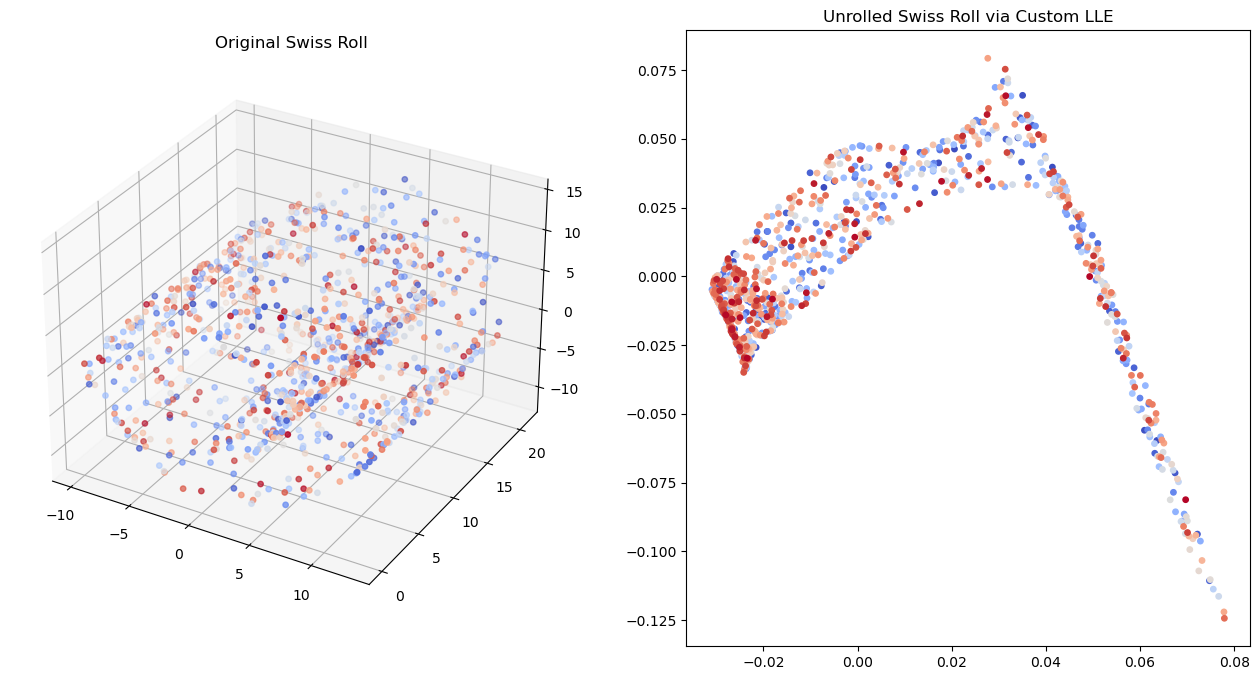

In [ ]:
# Visualization of the Swiss Roll and its unrolled version after applying LLE.
fig = plt.figure(figsize=(16, 8))

# The original Swiss Roll in 3D.
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=np.arange(n_points), cmap=plt.cm.coolwarm, s=15)
ax.set_title('Original Swiss Roll')

# The 2D representation of the Swiss Roll applying the custom LLE implementation.
ax = fig.add_subplot(1, 2, 2)
ax.scatter(X_reduced[:, 0], X_reduced[:, 1], c=np.arange(n_points), cmap=plt.cm.coolwarm, s=15)
ax.set_title('Unrolled Swiss Roll via Custom LLE')

# Display the plots generated for the Swiss Roll and its unrolled version.
plt.show()

###


<font size='+1'>**(c)**</font> Finally use the LLE implementation provided by Scikit-learn to check the results of your implementation. (plot your results)

<font color='#8FCF26' size='+2'>**c:**</font>

### $$\textbf{Custom LLE VS sklearn LLE}$$

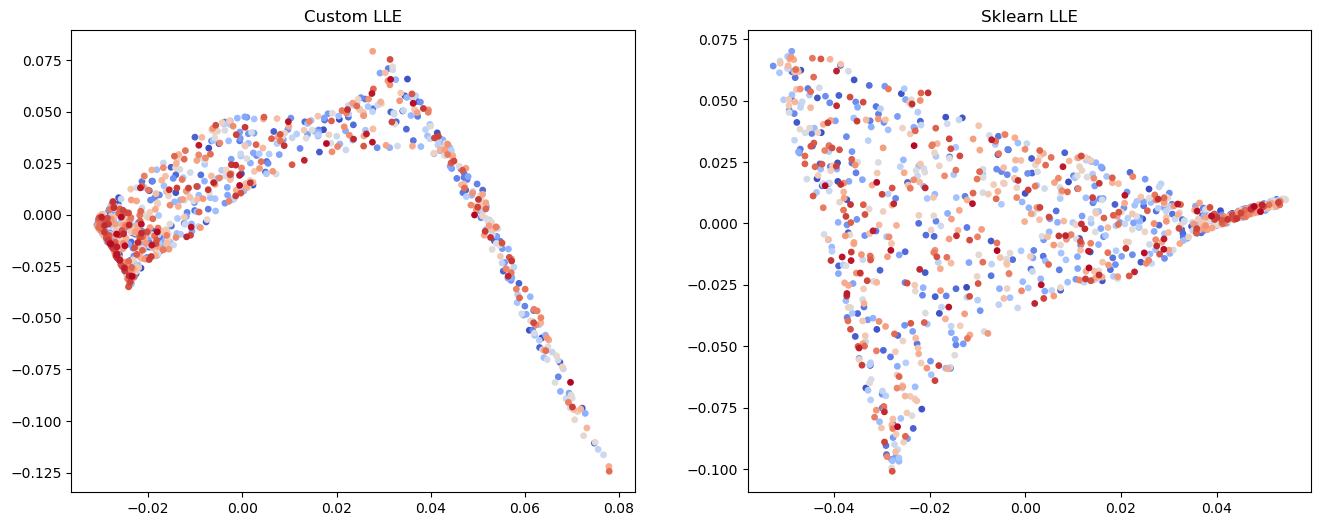

In [ ]:
from sklearn.manifold import LocallyLinearEmbedding

# Initialize an LLE model specifying the number of neighbors to consider for each point
# and the number of dimensions to reduce the data to.
lle = LocallyLinearEmbedding(n_neighbors=8, n_components=2)

# Apply the LLE algorithm to the Swiss roll dataset
mappedX_lle = lle.fit_transform(X_swiss)

# Set up a figure for plotting the original and new, dimensionally-reduced datasets.
fig = plt.figure(figsize=(16, 6))

# Add the first subplot which shows the result of the custom LLE.
ax = fig.add_subplot(1, 2, 1)
ax.scatter(X_reduced[:, 0], X_reduced[:, 1], c=np.arange(n_points), cmap=plt.cm.coolwarm, s=15)
ax.set_title('Custom LLE')


# Add the second subplot which shows the result of scikit-learn's LLE.
ax = fig.add_subplot(1, 2, 2)
ax.scatter(mappedX_lle[:, 0], mappedX_lle[:, 1], c=np.arange(n_points), cmap=plt.cm.coolwarm, s=15)
ax.set_title('Sklearn LLE')  # This title differentiates the subplot as the scikit-learn LLE result.

# Display both subplots. The two side-by-side visualizations allow for easy comparison between
# the custom LLE implementation and scikit-learn's LLE.
plt.show()

## <font color='#D61E85' size='+3'>**Q4:**</font> <font size='+2'> **t-SNE vs. UMAP ** </font>

In this question we need the first $5000$ images of Fashion-MNIST dataset. We want to reduce the dimension of these samples down to 2 so we can plot them. Here, we use t-SNE and UMAP to perform these reductions. You can use scatterplot with 10 different colors to demonstrate the class of each instance. After visulaization try to analyze your results and compare them with each other. Is there any pattern in these visualizations?


<font color='#8FCF26' size='+2'>**A4:**</font> Your explanations

### $$\textbf{Run the Models}$$

In [ ]:
import pandas as pd
import numpy as np
import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [ ]:

# Load the CSV files into Pandas dataframes
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df = pd.read_csv('fashion-mnist_test.csv')

# Extract the first 5000 images and their labels
X_train = train_df.iloc[:5000, 1:].values / 255.0  # Normalizing the pixel values
y_train = train_df.iloc[:5000, 0].values


In [ ]:
# Reduce the dimensionality using UMAP
reducer = umap.UMAP()
X_umap = reducer.fit_transform(X_train)


In [ ]:
# Reduce the dimensionality using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train)

/root/miniconda3/envs/ML-TeIAS/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/root/miniconda3/envs/ML-TeIAS/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


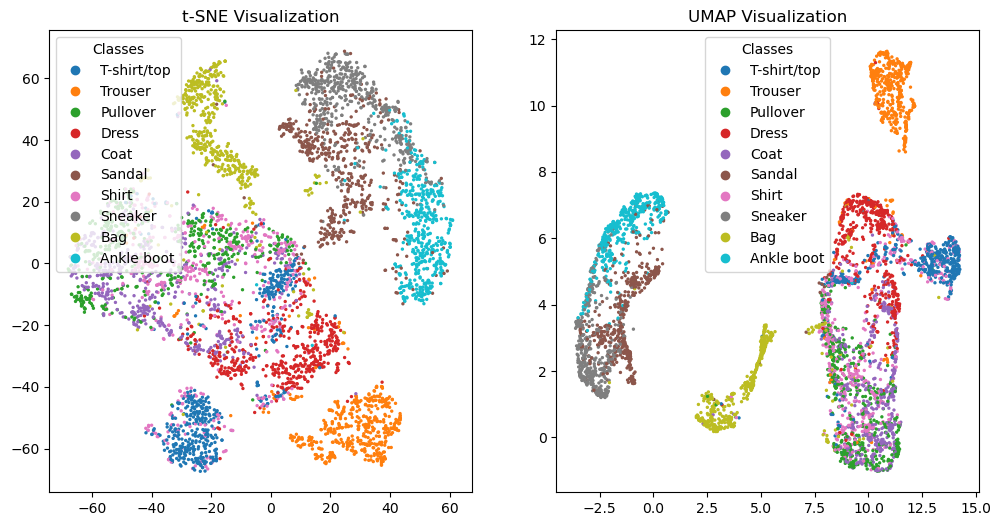

In [ ]:
# Define class names for Fashion-MNIST dataset
class_names = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

# Plot the t-SNE and UMAP visualizations side by side with class names in the legend
plt.figure(figsize=(12, 6))

# Plot t-SNE visualization with class names in legend
plt.subplot(1, 2, 1)
scatter_tsne = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='tab10', s=2)
plt.legend(handles=scatter_tsne.legend_elements()[0], labels=[class_names[i] for i in range(10)], title="Classes")
plt.title('t-SNE Visualization')

# Plot UMAP visualization with class names in legend
plt.subplot(1, 2, 2)
scatter_umap = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_train, cmap='tab10', s=2)
plt.legend(handles=scatter_umap.legend_elements()[0], labels=[class_names[i] for i in range(10)], title="Classes")
plt.title('UMAP Visualization')

plt.show()

### $$\textbf{Interpretation}$$

* Both t-SNE and UMAP have were successful in separating bags, footwear, upper-body wear, and lower-body wear categories. Which indicates that these categories have not many features in common.

* Ankle boots, sandals, and sneakers are close together and form a cluster in both models. Which makes sense as they all belong to the footwear category.

* The complete separation of bags and trousers into different clusters by both t-SNE and UMAP indicates that these two categories are way different than the other categories.

* Both models have seperate Dress from other upper-body wears quite good. However, other upper-body wear categories have musch overlap together in the visualizations which indicates hat they have a lot features in common.

## <font color='#D61E85' size='+3'>**Q5:**</font> <font size='+2'> **Iris** </font>

You will take a shortcut and load the Iris dataset from Scikit-learn’s datasets module. Furthermore, you will only select two features, sepal width and petal length, to make the classification task more challenging for illustration purposes

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import numpy as np

In [ ]:
# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Only select sepal width and petal length features (1st and 3rd features)
X = X[:, [1, 2]]

# Encode labels into integers
le = LabelEncoder()
y = le.fit_transform(y)

split the Iris examples into 50 percent training and 50 percent test data:

In [ ]:
# Split the Iris dataset into 50% training and 50% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1, stratify=y)

Using the training dataset, you now will train three different classifiers:

- Logistic regression classifier

- Decision tree classifier

- k-nearest neighbors classifier

you will then evaluate the model performance of each classifier via 10-fold cross-validation on the training dataset before combining them into an ensemble classifier:

<font color='#8FCF26' size='+2'>**Ans:**</font>
Now we’ll standardize the features and prepare the pipelines for each of the classifiers:

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Standardize the features
sc = StandardScaler()

# Create pipelines for each classifier

# Logistic Regression pipeline
pipe_lr = make_pipeline(StandardScaler(),
                        LogisticRegression(random_state=42))

# Decision Tree pipeline
pipe_dt = make_pipeline(StandardScaler(),
                        DecisionTreeClassifier(random_state=42))

# k-Nearest Neighbors pipeline
pipe_knn = make_pipeline(StandardScaler(),
                         KNeighborsClassifier())

# List of pipelines for ease of iteration
pipelines = [pipe_lr, pipe_dt, pipe_knn]

Now we will perform 10-fold cross-validation on the training data for each classifier:

In [ ]:
# Dictionary of pipelines and classifier types for ease of reference
pipe_dict = {0: 'Logistic Regression', 1: 'Decision Tree', 2: 'KNearest Neighbors'}

# Cross-validate each classifier
for idx, pipe in enumerate(pipelines):
    
    # Perform 10-fold cross-validation
    scores = cross_val_score(pipe, X_train, y_train, cv=10, scoring='accuracy')
    
    # Print classifier performance
    print(f'{pipe_dict[idx]}: ')
    print(f'Cross-validation accuracy: {np.mean(scores):.3f} +/- {np.std(scores):.3f}\n')

Logistic Regression: 
Cross-validation accuracy: 0.848 +/- 0.132

Decision Tree: 
Cross-validation accuracy: 0.877 +/- 0.114

KNearest Neighbors: 
Cross-validation accuracy: 0.930 +/- 0.095



Ensemble model using `Voting Classifier`:

In [ ]:
from sklearn.ensemble import VotingClassifier
# Combine pipelines into ensemble classifier using voting
# We use 'soft' voting to predict the class label
ensemble_clf = VotingClassifier(estimators=[
    ('lr', pipe_lr), ('dt', pipe_dt), ('knn', pipe_knn)], voting='soft')

# Fit ensemble classifier to the training data
ensemble_clf.fit(X_train, y_train)

# Evaluate the ensemble classifier via 10-fold cross-validation on the training dataset
ensemble_scores = cross_val_score(ensemble_clf, X_train, y_train, cv=10, scoring='accuracy')

# Print ensemble classifier performance
print('Ensemble classifier performance:')
print(f'Cross-validation accuracy: {np.mean(ensemble_scores):.3f} +/- {np.std(ensemble_scores):.3f}')

Ensemble classifier performance:
Cross-validation accuracy: 0.905 +/- 0.105


#### $$\textbf{Result Analysis - Individual Models}$$

* The KNearest Neighbors (KNN) classifier outperforms both the logistic regression and decision tree models. It has the highest accuracy at 93% and the lowest standard deviation, which shows that it has the most consistent results across data subsets.

* The decision tree model, has an 87.7% accuracy, is better than logistic regression and and has more stability than logistic regression.

* Logistic Regression shows the most variability with an 84.8% accuracy and a 13.2% standard deviation.

#### $$\textbf{Result Analysis - Ensemble Model}$$

* The KNN classifier is the strongest performer for this task, based on accuracy.

* The ensemble classifier helps to boost performance of some models ( logistic regression and the decision tree), but it does not outperform the best individual classifier (KNN) .

* * The ensemble model usually benefits from the different strengths of the individual classifiers, which usually leads to an improved model in generalizability and robustness. However, if one classifier is significantly better than the others (like KNN does in this situation), its influence in an ensemble may not be enough to outperform its individual accuracy.


## <font color='#D61E85' size='+3'>**Q6:**</font> <font size='+2'> **Carseats** </font>

#### Ensemble Learning

Ensemble learning is a machine learning technique that involves combining the predictions of multiple models to improve the overall performance and accuracy of a system. Instead of relying on a single model to make predictions, ensemble methods use a group of models and aggregate their predictions to achieve better results than any individual model could achieve on its own.

The basic idea behind ensemble learning is that by combining the strengths of different models, it is possible to mitigate the weaknesses of each individual model. Ensemble methods are often used to enhance predictive accuracy, reduce overfitting, and improve the robustness of the model.

There are several popular ensemble learning techniques, including:

**Bagging (Bootstrap Aggregating):** This method involves training multiple instances of the same learning algorithm on different subsets of the training data, typically created by random sampling with replacement. The predictions of these models are then averaged or voted upon to make the final prediction.

**Boosting:** Boosting focuses on training a sequence of weak learners, where each subsequent model corrects the errors of its predecessor. Popular boosting algorithms include AdaBoost (Adaptive Boosting) and Gradient Boosting.

**Random Forest:** Random Forest is an ensemble method based on bagging. It constructs multiple decision trees during training and combines their predictions through averaging or voting. Each tree in the forest is trained on a random subset of the features.

Stacking: Stacking involves training multiple diverse models and using another model (meta-model or blender) to combine their predictions. The predictions of individual models serve as input features for the meta-model.

Ensemble learning is a powerful technique that is widely used in various machine learning applications. It is particularly effective when dealing with complex and diverse datasets, as well as when individual models may have different strengths and weaknesses.

We are going to work with **Carseats** dataset. We want to predict the sales using regression trees and related approaches, treating the response as a quantitative variable.

- Load Dataset

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.tree import plot_tree

In [ ]:
# Load the dataset
carseats_df = pd.read_csv('Carseats.csv')

- Do preprocess
- Split the data set into a training set and a test set.

In [ ]:
carseats_df.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


In [ ]:
carseats_df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [ ]:
# Check and sum all null values for each column
null_values = carseats_df.isnull().sum()

# Print the number of null values for each column
print("Null values per column:")
print(null_values)


Null values per column:
Sales          0
CompPrice      0
Income         0
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            0
Education      0
Urban          0
US             0
dtype: int64


In [ ]:

# Check for columns with non-numerical data by listing data types
print("\nData types of each column:")
print(carseats_df.dtypes)



Data types of each column:
Sales          float64
CompPrice        int64
Income           int64
Advertising      int64
Population       int64
Price            int64
ShelveLoc       object
Age              int64
Education        int64
Urban           object
US              object
dtype: object


In [ ]:
non_numerical_columns = carseats_df.select_dtypes(include=['object']).columns

# Print non-numerical columns
print("Non-numerical columns:")
print(non_numerical_columns )


Non-numerical columns:
Index(['ShelveLoc', 'Urban', 'US'], dtype='object')


In [ ]:
for col in non_numerical_columns:
    print(f"\nUnique values in {col}:")
    print(carseats_df[col].unique())


Unique values in ShelveLoc:
['Bad' 'Good' 'Medium']

Unique values in Urban:
['Yes' 'No']

Unique values in US:
['Yes' 'No']


In [ ]:
# For the 'ShelveLoc' column, we can use Label Encoding with a custom mapping
shelveloc_mapping = {'Bad': 0, 'Medium': 1, 'Good': 2}
carseats_df['ShelveLoc'] = carseats_df['ShelveLoc'].map(shelveloc_mapping)

# For binary categories in 'Urban' and 'US', we can map 'Yes' to 1 and 'No' to 0
yes_no_mapping = {'Yes': 1, 'No': 0}
carseats_df['Urban'] = carseats_df['Urban'].map(yes_no_mapping)
carseats_df['US'] = carseats_df['US'].map(yes_no_mapping)

# Check the transformed columns
print(carseats_df[['ShelveLoc', 'Urban', 'US']])

     ShelveLoc  Urban  US
0            0      1   1
1            2      1   1
2            1      1   1
3            1      1   1
4            0      1   0
..         ...    ...  ..
395          2      1   1
396          1      0   1
397          1      1   1
398          0      1   1
399          2      1   1

[400 rows x 3 columns]


In [ ]:
# Preprocess the data (Assuming 'Sales' is the target variable)
# Convert categorical variables to dummy variables
carseats_df = pd.get_dummies(carseats_df, drop_first=True)

# Separate features and target variable
X = carseats_df.drop('Sales', axis=1) # Assuming 'Sales' is the name of the target column
y = carseats_df['Sales']

- Fit a regression tree to the training set. Plot the tree, and interpret
the results. What test MSE do you obtain?

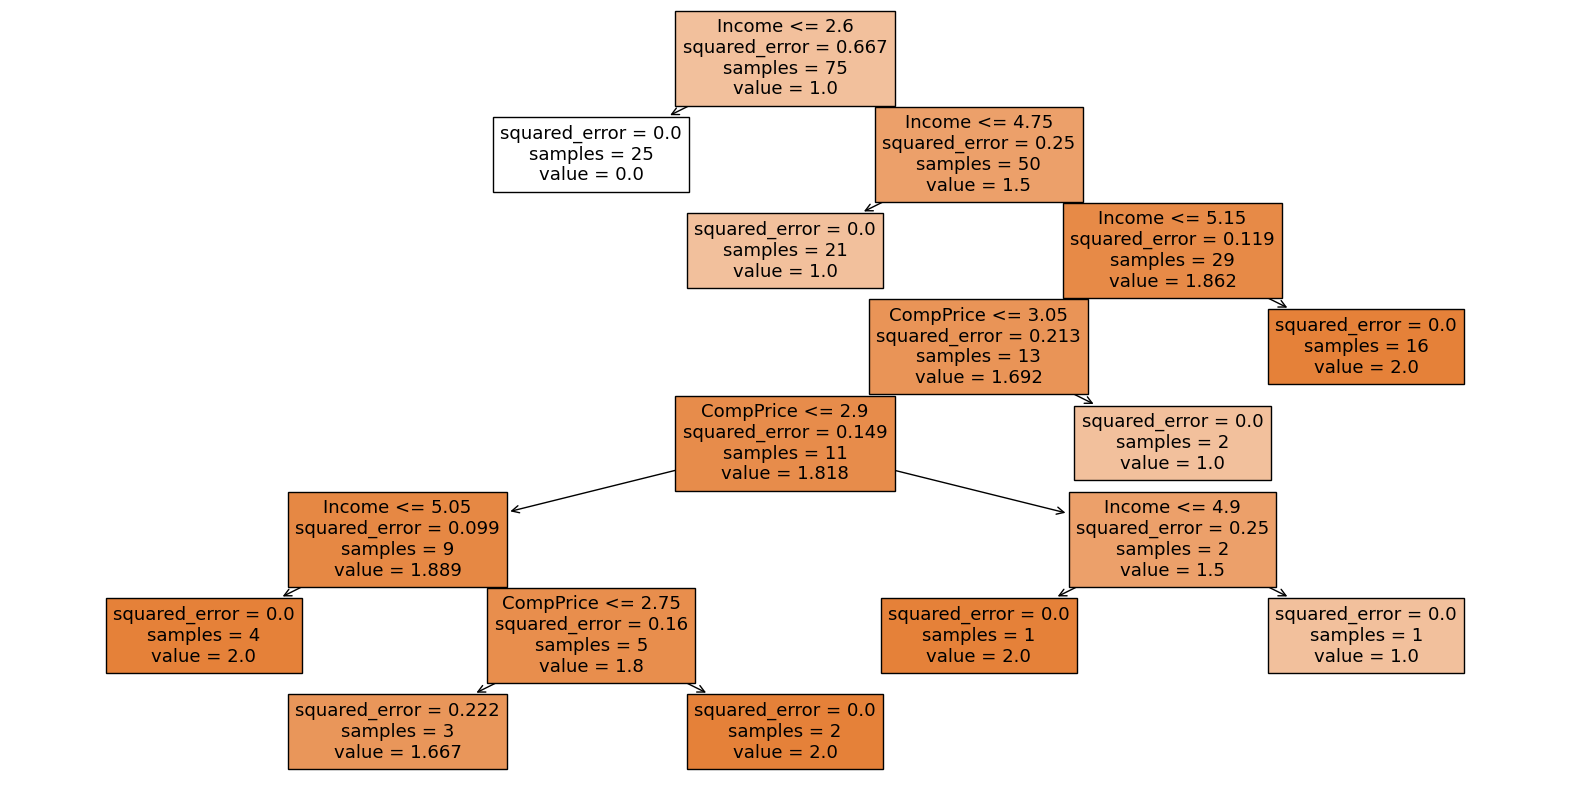

Test MSE for Decision Tree: 0.08


In [ ]:
# Fit a regression tree
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

# Plot the tree
plt.figure(figsize=(20,10)) # Set the size of the figure
plot_tree(tree_reg, filled=True, feature_names=X.columns)
plt.show()


In [ ]:
# Predict on test set
y_pred_tree = tree_reg.predict(X_test)

# Calculate MSE
mse_tree = mean_squared_error(y_test, y_pred_tree)
print(f'Test MSE for Decision Tree: {mse_tree}')

# Calculate R-squared
r2_tree = tree_reg.score(X_test, y_test)
print(f'Test R-squared for Decision Tree: {r2_tree}')

Test MSE for Decision Tree: 0.08
Test R-squared for Decision Tree: 0.88


- Use the bagging approach in order to analyze this data. What test MSE do you obtain? which variables are most important. visualize them

In [ ]:
# Bagging approach using RandomForest with default hyperparameters
bagging_reg = RandomForestRegressor(n_estimators=100, bootstrap=True, random_state=42)
bagging_reg.fit(X_train, y_train)

# Predict on test set and calculate MSE
y_pred_bagging = bagging_reg.predict(X_test)
mse_bagging = mean_squared_error(y_test, y_pred_bagging)
print(f'Test MSE for Bagging: {mse_bagging}')

# Calculate R-squared
r2_bagging = bagging_reg.score(X_test, y_test)
print(f'Test R-squared for Bagging: {r2_bagging}')

Test MSE for Bagging: 0.047969222231460475
Test R-squared for Bagging: 0.9280461666528093


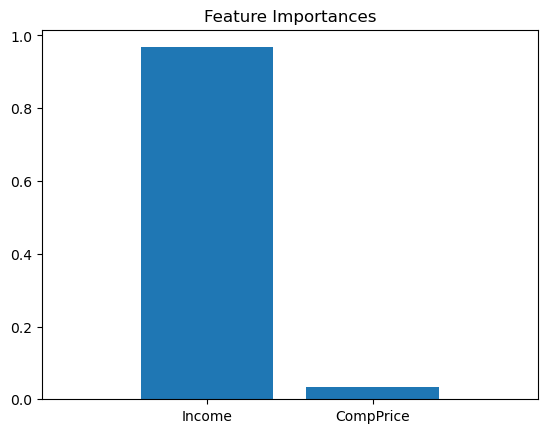

In [ ]:
# Feature importance
importances = bagging_reg.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot Feature Importance
plt.figure()
plt.title('Feature Importances')
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X.columns[indices])
plt.xlim([-1, X_train.shape[1]])
plt.show()

- Use random forests to analyze this data. What test MSE do you obtain?  which variables are most important. Describe the effect of m, the number of variables considered at each split, on the error rate obtained.

In [ ]:
from sklearn.metrics import r2_score

# Empty list to store results
results = []

# Try different numbers of features
for m in range(1, X_train.shape[1] + 1):
    # Configure the random forest to consider m features at each split
    rf_reg = RandomForestRegressor(n_estimators=100, max_features=m, random_state=42)
    rf_reg.fit(X_train, y_train)

    # Predict on test set and calculate MSE
    y_pred_rf = rf_reg.predict(X_test)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    r2_rf = r2_score(y_test, y_pred_rf)  # Calculate R-squared value
    
    # Append results
    results.append((m, mse_rf, r2_rf))


In [ ]:
# Convert results to a DataFrame and find the number of features that gave the lowest test MSE
results_df = pd.DataFrame(results, columns=['m', 'Test MSE', 'Test R-squared'])
best_m = results_df.loc[results_df['Test MSE'].idxmin()]

In [ ]:
# Print results
print(f"Best number of features m at each split: {best_m['m']}")
print(f"Test MSE for the best Random Forest model: {best_m['Test MSE']}")
print(f"Test R-squared for the best Random Forest model: {best_m['Test R-squared']}")

Best number of features m at each split: 2.0
Test MSE for the best Random Forest model: 0.047969222231460475
Test R-squared for the best Random Forest model: 0.9280461666528093


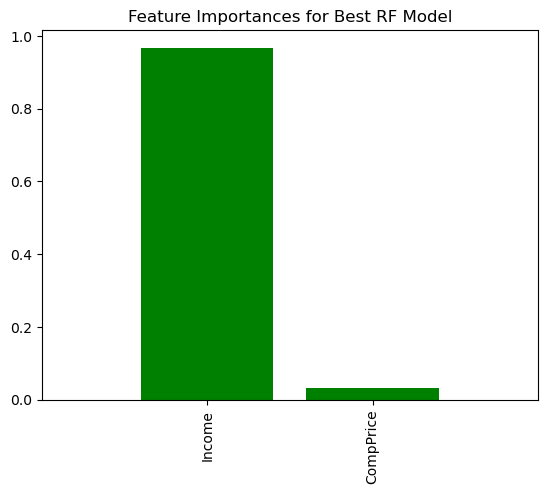

In [ ]:
# Feature importance for the best model
rf_reg_best = RandomForestRegressor(n_estimators=100, max_features=int(best_m['m']), random_state=42)
rf_reg_best.fit(X_train, y_train)

# Feature importance
importances_best = rf_reg_best.feature_importances_
indices_best = np.argsort(importances_best)[::-1]

# Plot Feature Importance for the best model
plt.figure()
plt.title('Feature Importances for Best RF Model')
plt.bar(range(X_train.shape[1]), importances_best[indices_best], color="g", align="center")
plt.xticks(range(X_train.shape[1]), X.columns[indices_best], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()